Epoch 100/1000, Training Loss: 97479.1953, Validation Loss: 128583.2734
Epoch 200/1000, Training Loss: 76210.3750, Validation Loss: 99902.0703
Epoch 300/1000, Training Loss: 70225.3906, Validation Loss: 90812.4766
Epoch 400/1000, Training Loss: 66818.8594, Validation Loss: 85540.9766
Epoch 500/1000, Training Loss: 64632.9844, Validation Loss: 82065.2969
Epoch 600/1000, Training Loss: 63139.8086, Validation Loss: 79621.9922
Epoch 700/1000, Training Loss: 62073.2344, Validation Loss: 77827.6016
Epoch 800/1000, Training Loss: 61284.6562, Validation Loss: 76465.0625
Epoch 900/1000, Training Loss: 60685.3242, Validation Loss: 75402.5156
Epoch 1000/1000, Training Loss: 60219.5469, Validation Loss: 74555.6484

Linear Regression Test Loss (MSE): 74555.6484
R-squared (R²): 0.9022


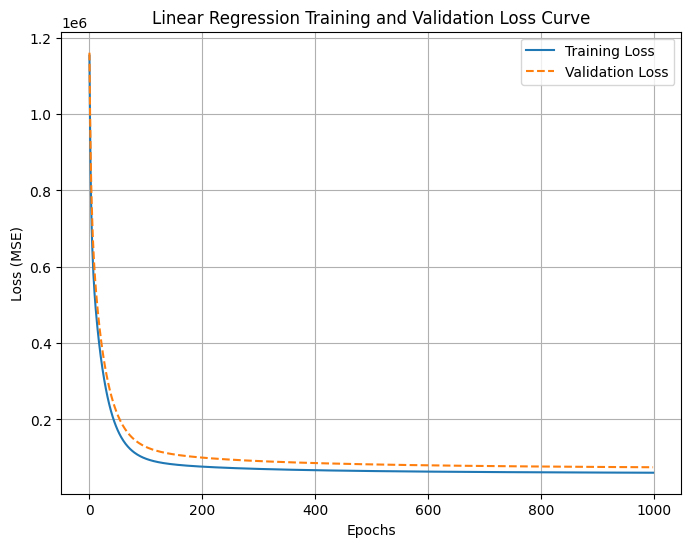

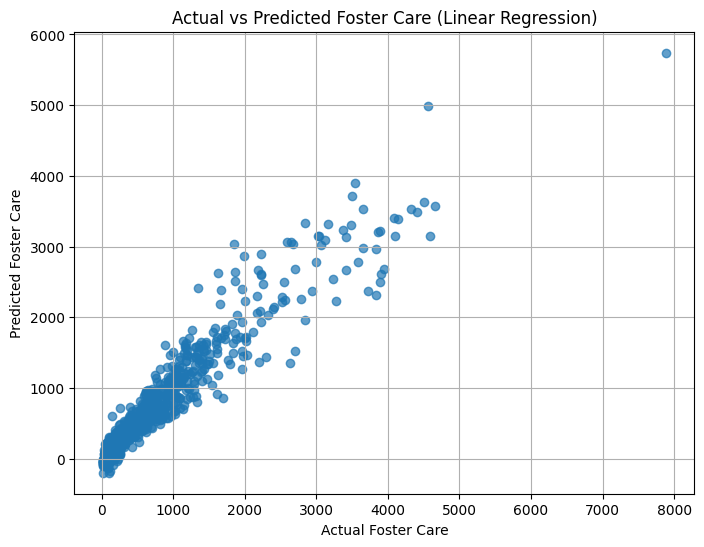

In [4]:
#Linear Regression
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Define the Linear Regression model
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

# Initialize the model
input_dim = X_train.shape[1]
linear_model = LinearRegressionModel(input_dim)

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.01)

# Train the model
epochs = 1000
training_losses = []
validation_losses = []
for epoch in range(epochs):
    # Forward pass for training
    y_pred = linear_model(X_train_tensor)
    train_loss = criterion(y_pred, y_train_tensor)
    training_losses.append(train_loss.item())

    # Backward pass and optimization
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Calculate validation loss
    with torch.no_grad():
        y_val_pred = linear_model(X_test_tensor)
        val_loss = criterion(y_val_pred, y_test_tensor)
        validation_losses.append(val_loss.item())

    # Log every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

# Evaluate the model
with torch.no_grad():
    y_test_pred = linear_model(X_test_tensor)
    test_loss = criterion(y_test_pred, y_test_tensor)
    print(f'\nLinear Regression Test Loss (MSE): {test_loss.item():.4f}')

    # R-squared calculation
    y_test_mean = y_test_tensor.mean()
    ss_total = ((y_test_tensor - y_test_mean) ** 2).sum()
    ss_residual = ((y_test_tensor - y_test_pred) ** 2).sum()
    r2 = 1 - ss_residual / ss_total
    print(f'R-squared (R²): {r2.item():.4f}')

# Visualizations
# 1. Training and Validation Loss Curves
plt.figure(figsize=(8, 6))
plt.plot(range(epochs), training_losses, label="Training Loss")
plt.plot(range(epochs), validation_losses, label="Validation Loss", linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Linear Regression Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# 2. Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_tensor.numpy(), y_test_pred.numpy(), alpha=0.7)
plt.xlabel("Actual Foster Care")
plt.ylabel("Predicted Foster Care")
plt.title("Actual vs Predicted Foster Care (Linear Regression)")
plt.grid(True)
plt.show()


Epoch 100/1000, Training Loss: 111473.3047, Validation Loss: 133126.0156
Epoch 200/1000, Training Loss: 95336.9062, Validation Loss: 107084.9141
Epoch 300/1000, Training Loss: 92971.5781, Validation Loss: 100316.1797
Epoch 400/1000, Training Loss: 92109.8828, Validation Loss: 96904.8438
Epoch 500/1000, Training Loss: 91741.2656, Validation Loss: 94926.8047
Epoch 600/1000, Training Loss: 91572.8906, Validation Loss: 93706.3438
Epoch 700/1000, Training Loss: 91492.4453, Validation Loss: 92924.0547
Epoch 800/1000, Training Loss: 91452.6172, Validation Loss: 92409.0547
Epoch 900/1000, Training Loss: 91432.3594, Validation Loss: 92063.1875
Epoch 1000/1000, Training Loss: 91421.8203, Validation Loss: 91827.2891

Ridge Regression Test Loss (MSE): 91827.2891
R-squared (R²): 0.8796


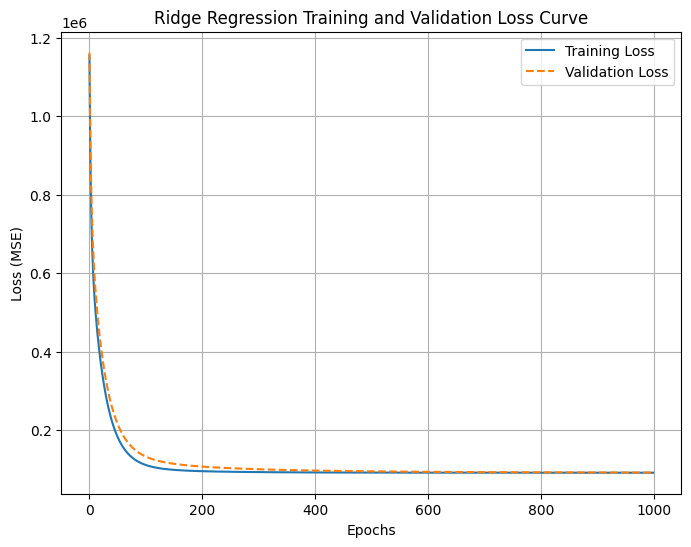

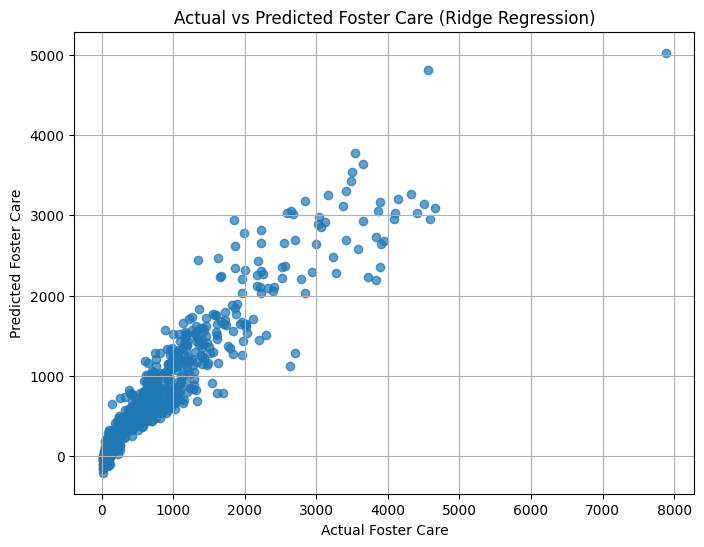

In [5]:
# Ridge Regression Model
ridge_model = LinearRegressionModel(input_dim)

# Define the optimizer and L2 regularization strength
lambda_l2 = 0.1  # Regularization strength
optimizer = torch.optim.SGD(ridge_model.parameters(), lr=0.01)

# Train the model with L2 regularization
training_losses = []
validation_losses = []
for epoch in range(epochs):
    # Forward pass for training
    y_pred = ridge_model(X_train_tensor)
    mse_loss = criterion(y_pred, y_train_tensor)

    # Add L2 regularization (exclude bias)
    l2_loss = lambda_l2 * sum(param.pow(2).sum() for name, param in ridge_model.named_parameters() if 'bias' not in name)
    train_loss = mse_loss + l2_loss
    training_losses.append(train_loss.item())

    # Backward pass and optimization
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Calculate validation loss
    with torch.no_grad():
        y_val_pred = ridge_model(X_test_tensor)
        val_loss = criterion(y_val_pred, y_test_tensor)
        validation_losses.append(val_loss.item())

    # Log progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')

# Evaluate the model
with torch.no_grad():
    y_test_pred = ridge_model(X_test_tensor)
    test_loss = criterion(y_test_pred, y_test_tensor)
    print(f'\nRidge Regression Test Loss (MSE): {test_loss.item():.4f}')

    # R-squared calculation
    y_test_mean = y_test_tensor.mean()
    ss_total = ((y_test_tensor - y_test_mean) ** 2).sum()
    ss_residual = ((y_test_tensor - y_test_pred) ** 2).sum()
    r2 = 1 - ss_residual / ss_total
    print(f'R-squared (R²): {r2.item():.4f}')

# Visualizations
# 1. Training and Validation Loss Curves
plt.figure(figsize=(8, 6))
plt.plot(range(epochs), training_losses, label="Training Loss")
plt.plot(range(epochs), validation_losses, label="Validation Loss", linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Ridge Regression Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# 2. Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_tensor.numpy(), y_test_pred.numpy(), alpha=0.7)
plt.xlabel("Actual Foster Care")
plt.ylabel("Predicted Foster Care")
plt.title("Actual vs Predicted Foster Care (Ridge Regression)")
plt.grid(True)
plt.show()


Epoch 100: Training Loss = 57495.7533, Validation Loss = 68695.2895
Epoch 200: Training Loss = 57096.9881, Validation Loss = 68241.4924
Epoch 300: Training Loss = 56869.2335, Validation Loss = 67974.4450
Epoch 400: Training Loss = 56725.6961, Validation Loss = 67798.1878
Epoch 500: Training Loss = 56630.2906, Validation Loss = 67674.8536
Epoch 600: Training Loss = 56564.5965, Validation Loss = 67585.0744
Epoch 700: Training Loss = 56518.1680, Validation Loss = 67517.7510
Epoch 800: Training Loss = 56484.6777, Validation Loss = 67466.0536
Epoch 900: Training Loss = 56460.1126, Validation Loss = 67425.5637
Epoch 1000: Training Loss = 56441.8382, Validation Loss = 67393.3124
Epoch 1100: Training Loss = 56428.0775, Validation Loss = 67367.2444
Epoch 1200: Training Loss = 56417.6053, Validation Loss = 67345.9010
Epoch 1300: Training Loss = 56409.5610, Validation Loss = 67328.2247
Epoch 1400: Training Loss = 56403.3306, Validation Loss = 67313.4350
Epoch 1500: Training Loss = 56398.4695, Val

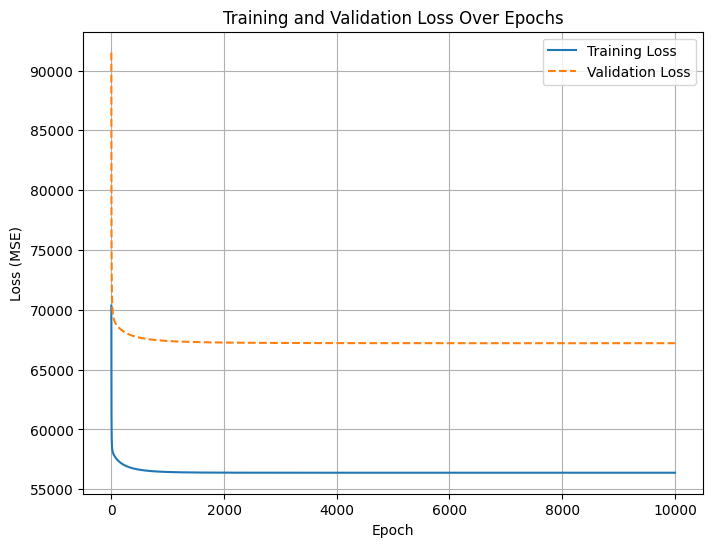

In [3]:
#S
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor  # Stochastic Gradient Descent for Linear Regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load data directly from the GitHub URL
url = 'https://raw.githubusercontent.com/mewert17/MachineLearning/refs/heads/main/OrganizedFinalData.csv'
df = pd.read_csv(url)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'MedianAnnualFamilyIncome', 'Person', 'IHSS',
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI',
    'Native_American', 'Other_missing', 'Female', 'Male'
]
categorical_columns = ['Program']  # Categorical column to encode
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Encode categorical columns using one-hot encoding
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Ensure all feature columns are updated after encoding
feature_columns = [col for col in df.columns if col != target_column and col not in ['District', 'Level', 'Number']]

# Split data into features (X) and target (y)
X = df[feature_columns]
y = df[target_column]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data for SGDRegressor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the model
sgd_model = SGDRegressor(max_iter=1, learning_rate='invscaling', eta0=0.01, random_state=42, warm_start=True)

# Record loss during training and validation
training_losses = []
validation_losses = []
epochs = 10000

for epoch in range(1, epochs + 1):
    # Train the model on the training set
    sgd_model.partial_fit(X_train, y_train)

    # Calculate training loss
    y_train_pred = sgd_model.predict(X_train)
    train_loss = mean_squared_error(y_train, y_train_pred)
    training_losses.append(train_loss)

    # Calculate validation (test) loss
    y_test_pred = sgd_model.predict(X_test)
    val_loss = mean_squared_error(y_test, y_test_pred)
    validation_losses.append(val_loss)

    # Output losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

# Final evaluation
y_pred = sgd_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs + 1), training_losses, label="Training Loss")
plt.plot(range(1, epochs + 1), validation_losses, label="Validation Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.show()
